In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
data = pd.read_csv('Social_Network_Ads.csv')
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [84]:
x = data.iloc[:, :-1].values

In [85]:
x.shape

(400, 2)

In [86]:
y = data.iloc[:, -1].values

In [87]:
y.shape

(400,)

In [88]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20)

In [89]:
x_train.shape

(320, 2)

In [90]:
x_test.shape

(80, 2)

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [92]:
x_train = scaler.fit_transform(x_train)
x_train


array([[ 0.22491938, -0.38816683],
       [ 0.32297688, -1.20317567],
       [ 1.98995432, -0.69002195],
       [-0.85371308, -0.26742478],
       [-1.44205806,  0.36647099],
       [ 0.22491938,  0.03443035],
       [-1.54011556, -1.29373221],
       [-0.06925311,  2.02667419],
       [-1.63817305,  0.06461586],
       [-0.2653681 ,  0.09480138],
       [-0.1673106 ,  0.87962471],
       [-1.24594307, -1.11261913],
       [-0.06925311,  0.24572894],
       [-0.95177058,  0.51739855],
       [ 2.18606932,  1.15129432],
       [-0.46148309, -1.2635467 ],
       [-0.55954059,  1.42296393],
       [ 1.89189683,  1.5738915 ],
       [ 1.20549435, -1.02206259],
       [ 0.02880439, -0.26742478],
       [-0.95177058, -1.14280464],
       [ 0.02880439,  1.27203637],
       [ 0.12686189,  1.09092329],
       [-0.1673106 , -0.47872337],
       [ 1.79383933, -0.29761029],
       [-1.04982807,  0.57776958],
       [-0.06925311, -0.38816683],
       [ 0.42103438, -0.50890888],
       [-0.2653681 ,

In [93]:
x_train.shape

(320, 2)

In [94]:
x_test = scaler.transform(x_test)
x_test

array([[ 0.02880439, -0.26742478],
       [-1.14788557, -1.62577285],
       [-1.83428805, -1.47484528],
       [ 1.20549435, -1.5050308 ],
       [-1.04982807,  0.42684202],
       [-0.2653681 , -0.26742478],
       [ 1.98995432, -1.41447426],
       [ 1.49966684,  2.20778726],
       [-0.2653681 , -1.41447426],
       [-0.2653681 , -0.3277958 ],
       [ 0.02880439, -0.59946542],
       [-0.2653681 ,  0.27591445],
       [ 0.32297688, -0.3277958 ],
       [ 1.00937936,  1.48333496],
       [ 1.69578183,  1.66444804],
       [-0.06925311,  0.03443035],
       [-0.46148309, -0.87113503],
       [-0.75565558,  0.27591445],
       [-0.75565558,  0.57776958],
       [ 0.91132186, -1.35410323],
       [ 1.89189683, -0.29761029],
       [-1.83428805,  0.00424484],
       [-0.95177058,  0.57776958],
       [-0.2653681 ,  0.54758407],
       [-0.06925311,  0.21554343],
       [ 1.00937936, -1.11261913],
       [-0.55954059,  0.90981022],
       [-1.73623055,  0.12498689],
       [-1.14788557,

In [95]:
# 1 method : K selection Heurastic approach -> sqrt root of n

np.sqrt(x_train.shape[0])


17.88854381999832

In [96]:
k = 17

In [97]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = k)

In [98]:
# Train our model
knn.fit(x_train, y_train)


KNeighborsClassifier(n_neighbors=17)

In [99]:
y_pred = knn.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0], dtype=int64)

In [100]:
y_pred.shape

(80,)

In [101]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9375

In [102]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[48,  4],
       [ 1, 27]], dtype=int64)

In [103]:
# second method : try and error and find K value 

In [104]:
accuracy = []

for i in range (1,26):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    accuracy.append(accuracy_score(y_test, knn.predict(x_test)))

accuracy
    


[0.85,
 0.9,
 0.9,
 0.925,
 0.9125,
 0.9375,
 0.95,
 0.95,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.95,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.925,
 0.9375,
 0.9375,
 0.9375,
 0.925,
 0.9375,
 0.925,
 0.9375]

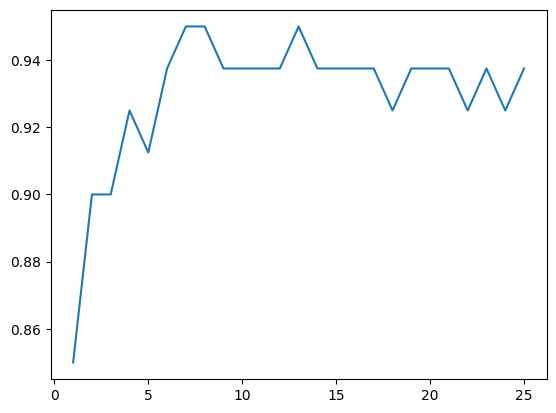

In [105]:
plt.plot(range(1,26),accuracy)

In [130]:
# Testing model

def predict_output():
    age = int(input("enter your age"))
    salary = int(input("enter your salary"))

    x_new = np.array([[age],[salary]]).reshape(1,2)
    x_new = scaler.transform(x_new)

    if knn.predict(x_new)[0] == 0:
        return "Will not purchase"
    else:
        return "will purchase"

predict_output()

enter your age 25
enter your salary 200000000000


'will purchase'

In [ ]:
# Decision Boundary

In [114]:
# creating a mishgrid
a = np.arange(start = x_train[:,0].min()-1, stop = x_train[:,0].max() + 1, step = 0.01)
b = np.arange(start = x_train[:,1].min()-1, stop = x_train[:,1].max() + 1, step = 0.01)

XX, YY = np.meshgrid(a,b)

print(XX)
YY.shape



[[-2.93234554 -2.92234554 -2.91234554 ...  3.15765446  3.16765446
   3.17765446]
 [-2.93234554 -2.92234554 -2.91234554 ...  3.15765446  3.16765446
   3.17765446]
 [-2.93234554 -2.92234554 -2.91234554 ...  3.15765446  3.16765446
   3.17765446]
 ...
 [-2.93234554 -2.92234554 -2.91234554 ...  3.15765446  3.16765446
   3.17765446]
 [-2.93234554 -2.92234554 -2.91234554 ...  3.15765446  3.16765446
   3.17765446]
 [-2.93234554 -2.92234554 -2.91234554 ...  3.15765446  3.16765446
   3.17765446]]


(608, 612)

In [117]:
# Classifiying every point on the meshgrid

input_array = np.array([XX.ravel(), YY.ravel()]).T


In [121]:
lables = knn.predict(input_array)

In [122]:
lables

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [123]:
# Plotting the array as an image

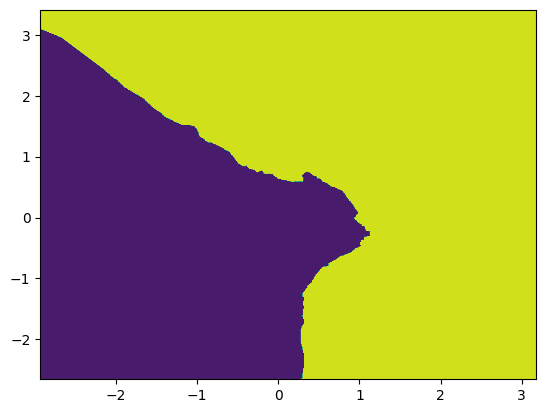

In [125]:
plt.contourf(XX,YY,lables.reshape(XX.shape))

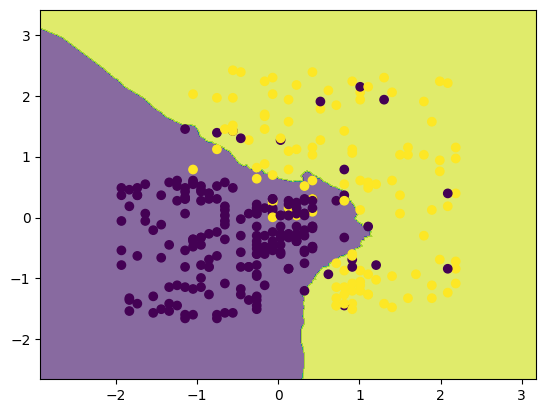

In [128]:
plt.contourf(XX,YY,lables.reshape(XX.shape), alpha = 0.65)
plt.scatter(x_train[:,0],x_train[:,1], c=y_train)